In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values (0 to 255 → 0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Class labels
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)


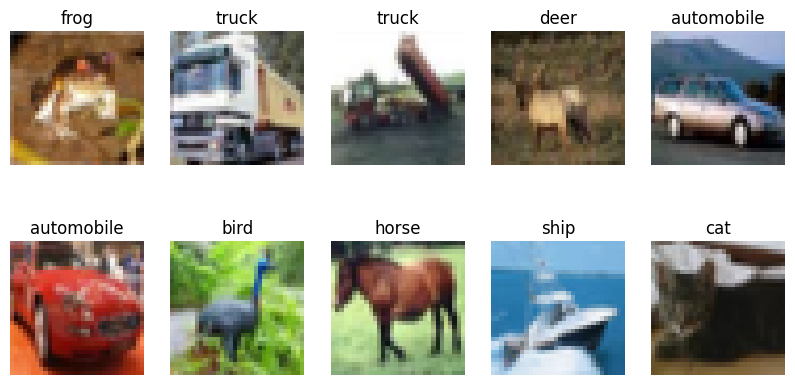

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [5]:
model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(32,(3,3),activation='relu',
                        input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(layers.Conv2D(64,(3,3),activation='relu'))

# Flattening
model.add(layers.Flatten())

# Fully Connected Layer
model.add(layers.Dense(64,activation='relu'))

# Output Layer
model.add(layers.Dense(10,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.4372 - loss: 1.5460 - val_accuracy: 0.5347 - val_loss: 1.2681
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.5817 - loss: 1.1751 - val_accuracy: 0.5839 - val_loss: 1.1564
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.6378 - loss: 1.0159 - val_accuracy: 0.6508 - val_loss: 0.9793
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6769 - loss: 0.9146 - val_accuracy: 0.6766 - val_loss: 0.9343
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.7024 - loss: 0.8472 - val_accuracy: 0.6853 - val_loss: 0.8923
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7261 - loss: 0.7854 - val_accuracy: 0.6822 - val_loss: 0.9269
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7426 - loss: 0.7385 - val_accuracy: 0.7050 - val_loss: 0.8559
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7604 -

In [8]:
test_loss,test_acc = model.evaluate(x_test,y_test)

print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7157 - loss: 0.8638
Test Accuracy: 0.7156999707221985


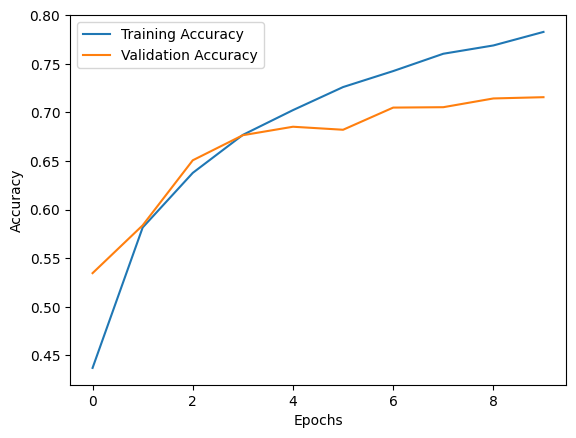

In [9]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


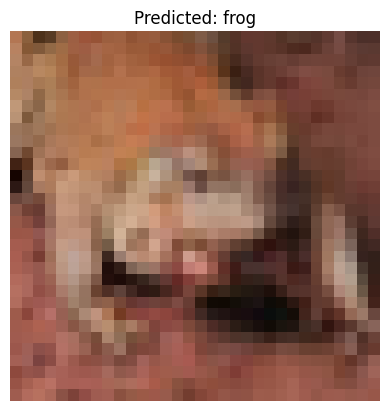

In [10]:
predictions = model.predict(x_test)

index = 5

plt.imshow(x_test[index])
plt.title("Predicted: "+class_names[np.argmax(predictions[index])])
plt.axis('off')
plt.show()

In [11]:
# Create model to extract feature maps
feature_model = models.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

# Select one image
sample = x_test[0].reshape(1,32,32,3)

feature_maps = feature_model.predict(sample)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
(1, 30, 30, 32)


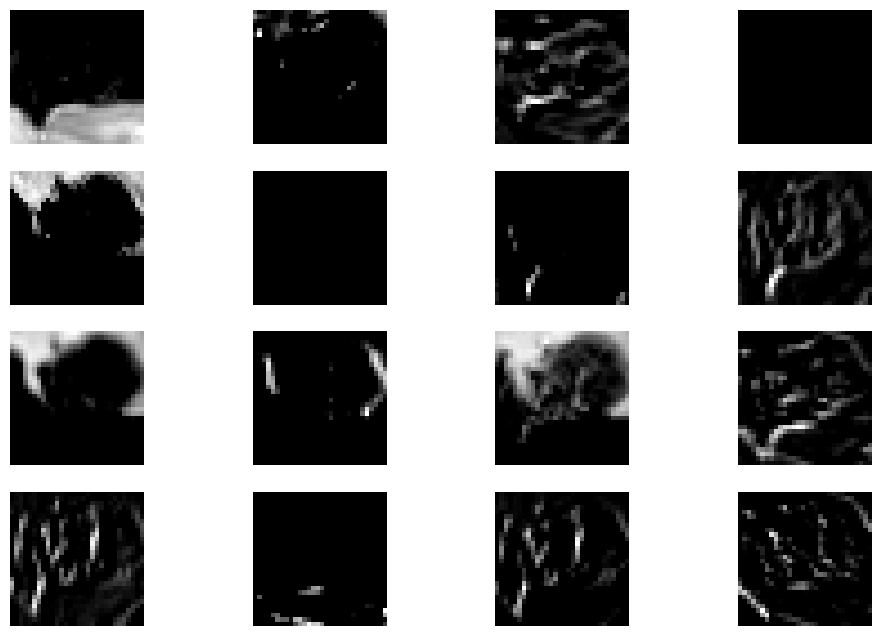

In [12]:
plt.figure(figsize=(12,8))

for i in range(16):  # first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.show()